In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [4]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


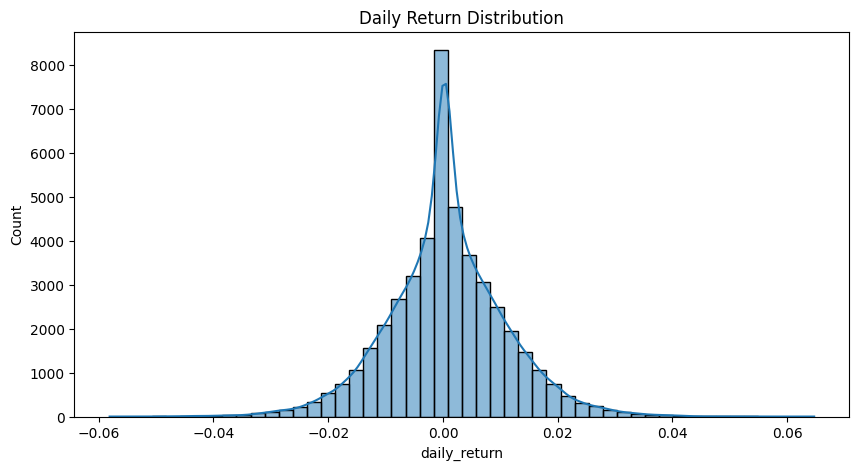

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

In [7]:
cagr_data = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df["date"].max() -
         df["date"].min()).days
        / 365
    )

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_data.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
rf = 0.065

In [9]:
sharpe = []

for code in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"]==code
    ]["daily_return"].dropna()

    sr = (
        (r.mean()*252 - rf)
        /
        (r.std())
    ) * np.sqrt(252)

    sharpe.append(
        [code,sr]
    )

sharpe_df = pd.DataFrame(
    sharpe,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


In [12]:
sortino = []

for code in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"]==code
    ]["daily_return"].dropna()

    downside = r[r < 0]

    sortino_ratio = (
        (r.mean()*252 - rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino.append(
        [code,sortino_ratio]
    )

sortino_df = pd.DataFrame(
    sortino,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [11]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [13]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [14]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [15]:
nifty100 = benchmark[
    benchmark["index_name"] == "Nifty 100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [16]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [code, alpha, beta]
        )

In [17]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta


In [18]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [22]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [23]:
mdd = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==code
    ].copy()

    df["running_max"] = (
        df["nav"].cummax()
    )

    df["drawdown"] = (
        df["nav"]
        /
        df["running_max"]
        - 1
    )

    mdd.append(
        [
            code,
            df["drawdown"].min()
        ]
    )

mdd_df = pd.DataFrame(
    mdd,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [24]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(sortino_df)
    .merge(mdd_df)
)

In [25]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [26]:
scorecard["fund_score"] = (

    scorecard["return_rank"]*30 +

    scorecard["sharpe_rank"]*25 +

    scorecard["dd_rank"]*10

)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,return_rank,sharpe_rank,dd_rank,fund_score
0,100016,0.026352,-50.782301,-88.463960,-0.247344,0.100,0.150,0.850,15.250
1,100025,0.044551,-142.907888,-237.338952,-0.043083,0.125,0.050,0.100,6.000
2,100033,0.300997,275.612083,460.941758,-0.162172,0.850,0.850,0.500,51.750
3,101206,0.235205,258.857759,453.489844,-0.112916,0.725,0.800,0.225,44.000
4,101207,0.079331,40.990514,69.714237,-0.354469,0.350,0.325,0.950,28.125


In [27]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [28]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [29]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [30]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [31]:
scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["fund_score"] = (
    scorecard["return_rank"] * 30 +
    scorecard["sharpe_rank"] * 25 +
    scorecard["alpha_rank"] * 20 +
    scorecard["dd_rank"] * 10
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,return_rank,sharpe_rank,dd_rank,fund_score,alpha,beta,alpha_rank
0,100016,0.026352,-50.782301,-88.463960,-0.247344,0.100,0.150,0.850,NaN,NaN,NaN,NaN
1,100025,0.044551,-142.907888,-237.338952,-0.043083,0.125,0.050,0.100,NaN,NaN,NaN,NaN
2,100033,0.300997,275.612083,460.941758,-0.162172,0.850,0.850,0.500,NaN,NaN,NaN,NaN
3,101206,0.235205,258.857759,453.489844,-0.112916,0.725,0.800,0.225,NaN,NaN,NaN,NaN
4,101207,0.079331,40.990514,69.714237,-0.354469,0.350,0.325,0.950,NaN,NaN,NaN,NaN


In [32]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [33]:
import os

os.listdir("../reports")

['age_group_distribution.png',
 'alpha_beta.csv',
 'chart.png',
 'chart_name.png',
 'data_quality_summary.txt.txt',
 'fund_scorecard.csv',
 'gender_distribution.png',
 'nav_trend.png',
 'sip_amount_by_age_group.png',
 't30_b30_distribution.png']

In [34]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

top5_codes

[100016, 100025, 100033, 101206, 101207]

In [36]:
top_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top_nav["cum_return"] = (
    1 +
    top_nav["daily_return"].fillna(0)
).groupby(
    top_nav["amfi_code"]
).cumprod()

In [37]:
nifty = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50","NIFTY100"]
    )
].copy()

nifty = nifty.sort_values(
    ["index_name","date"]
)

nifty["benchmark_return"] = (
    nifty.groupby("index_name")
    ["close_value"]
    .pct_change()
)

nifty["cum_return"] = (
    1 +
    nifty["benchmark_return"].fillna(0)
).groupby(
    nifty["index_name"]
).cumprod()

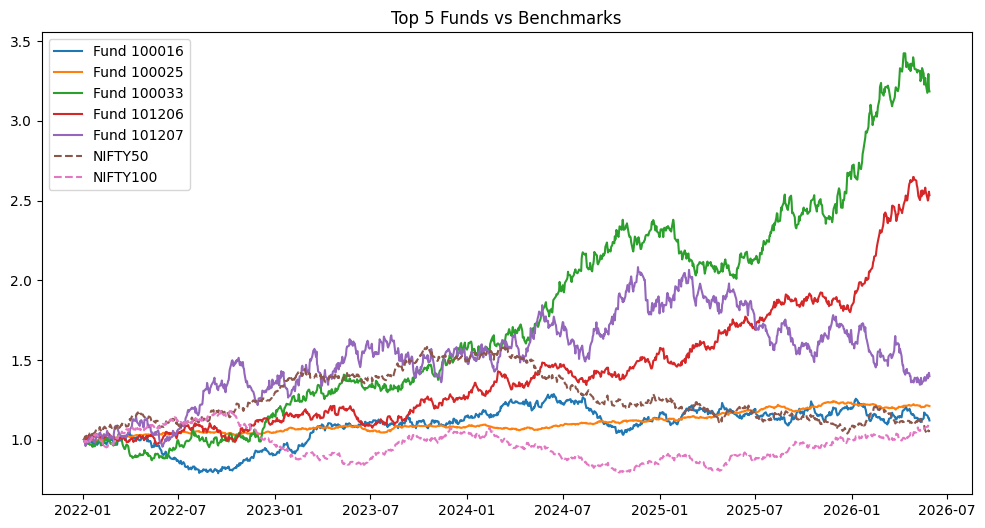

In [38]:
plt.figure(figsize=(12,6))

for code in top5_codes:

    df = top_nav[
        top_nav["amfi_code"] == code
    ]

    plt.plot(
        df["date"],
        df["cum_return"],
        label=f"Fund {code}"
    )

for idx in ["NIFTY50","NIFTY100"]:

    df = nifty[
        nifty["index_name"] == idx
    ]

    plt.plot(
        df["date"],
        df["cum_return"],
        linestyle="--",
        label=idx
    )

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.legend()

plt.show()

In [39]:
tracking_error = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    benchmark_returns = nifty[
        nifty["index_name"]=="NIFTY100"
    ][["date","benchmark_return"]]

    merged = pd.merge(
        fund,
        benchmark_returns,
        on="date"
    ).dropna()

    te = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_error.append(
        [code, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [40]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [41]:
import os

os.listdir("../reports")

['age_group_distribution.png',
 'alpha_beta.csv',
 'benchmark_comparison.png',
 'chart.png',
 'chart_name.png',
 'data_quality_summary.txt.txt',
 'fund_scorecard.csv',
 'gender_distribution.png',
 'nav_trend.png',
 'sip_amount_by_age_group.png',
 't30_b30_distribution.png',
 'tracking_error.csv']